In [36]:
# load the three LI datasets and combine them
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
banc = pd.read_csv('flywire/BANC/banc-ORN-LI.csv')
malecns = pd.read_csv('neuprint/male-cns-ORN-LI.csv')
fafb = pd.read_csv('flywire/fafb-ORN-LI.csv')

In [38]:
banc

,ORN_type,LI_partner,LI_synapse,ORN_side
0,ORN_VM5v,-0.411765,-0.213483,left
1,ORN_VM5v,1.000000,1.000000,left
2,ORN_VA6,-0.333333,0.059829,left
3,NaN,1.000000,1.000000,right
4,ORN_DM5,1.000000,1.000000,left
...,...,...,...,...
1667,ORN_VA3,-0.600000,-0.490196,left
1668,ORN_VM7d,-0.304348,-0.200000,right
1669,ORN_VM3,-0.636364,-0.417476,right
1670,ORN_VM3,-0.294118,0.175676,right


In [39]:
malecns

,ORN_type,LI_partner,LI_synapse,ORN_side
0,ORN_VA1v,0.542373,0.392157,1
1,ORN_VA2,0.222642,0.050524,1
2,ORN_VM6v,0.353474,0.390698,1
3,ORN_VM6v,0.466292,0.458811,1
4,ORN_VA1v,0.446809,0.386957,1
...,...,...,...,...
2634,ORN_DL4,-0.076923,-0.007576,-1
2635,ORN_VM2,1.000000,1.000000,-1
2636,ORN_DL3,0.000000,0.000000,0
2637,ORN_VM2,0.000000,0.000000,0


In [40]:
fafb

,ORN_type,ORN_side,receptor,LI_partner,LI_synapse
0,ORN_DM2,right,"Or22,Or22a,Or22b",-0.057143,-0.007407
1,ORN_VM5d,left,"Or85b,Or98b",0.122807,0.114583
2,ORN_VA7m,left,unknown,0.014493,0.108527
3,ORN_DA3,right,Or23a,-0.333333,-0.333333
4,ORN_DA2,right,"Or33a,Or56a",0.290323,0.333333
...,...,...,...,...,...
2242,ORN_DA4m,right,Or2a,0.241379,0.315217
2243,ORN_DL1,left,Or10a,0.156250,0.235556
2244,ORN_DM6,right,Or67a,0.307692,0.367876
2245,ORN_DA1,left,Or67d,0.027778,-0.095477


In [41]:
# merge the three datasets
banc['source'] = 'BANC'
malecns['source'] = 'MCNS'
fafb['source'] = 'FAFB'
result_df = pd.concat([banc, malecns, fafb], axis=0, ignore_index=True)
result_df.to_csv('combined-ORN-LI.csv', index=False)

/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_35590/3009756936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ORN_type', y='LI_partner', data=result_df, order=order, fliersize=0, palette='vlag', showcaps=False)


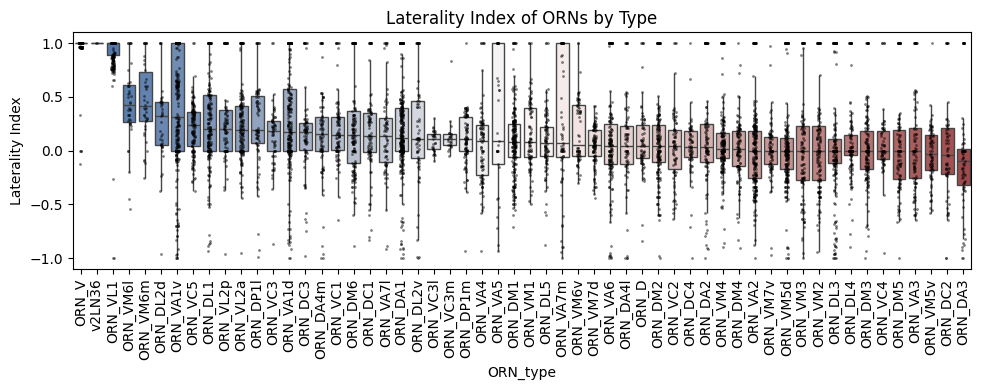

In [42]:
# plot aggregate laterality index by type (sorted by median laterality index)
order = result_df.groupby('ORN_type')['LI_partner'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,4))
sns.boxplot(x='ORN_type', y='LI_partner', data=result_df, order=order, fliersize=0, palette='vlag', showcaps=False)
sns.stripplot(x='ORN_type', y='LI_partner', data=result_df, order=order, color='k', size=2, alpha=0.5, jitter=True)
plt.xticks(rotation=90)
plt.ylabel('Laterality Index')
plt.title('Laterality Index of ORNs by Type')
plt.tight_layout()
plt.show()


/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_35590/3551547075.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ORN_type', y='LI_synapse', data=result_df, order=order, fliersize=0, palette='vlag', showcaps=False)


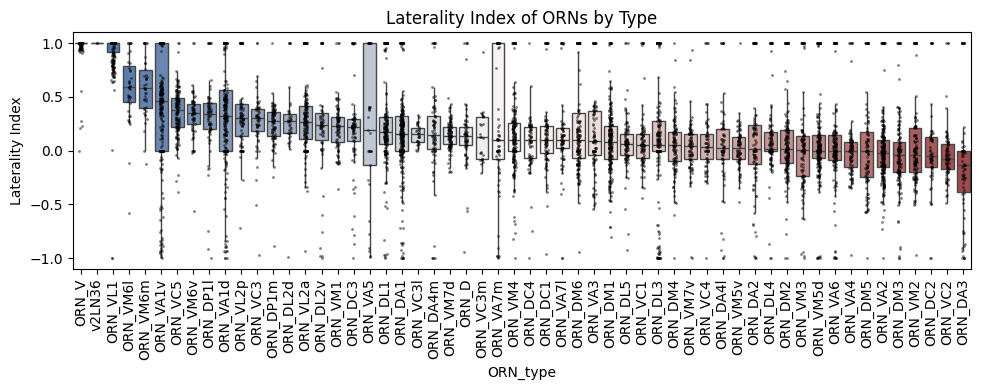

In [44]:
# plot aggregate laterality index by type (sorted by median laterality index)
order = result_df.groupby('ORN_type')['LI_synapse'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,4))
sns.boxplot(x='ORN_type', y='LI_synapse', data=result_df, order=order, fliersize=0, palette='vlag', showcaps=False)
sns.stripplot(x='ORN_type', y='LI_synapse', data=result_df, order=order, color='k', size=2, alpha=0.5, jitter=True)
plt.xticks(rotation=90)
plt.ylabel('Laterality Index')
plt.title('Laterality Index of ORNs by Type')
plt.tight_layout()
plt.show()


In [ ]:
#

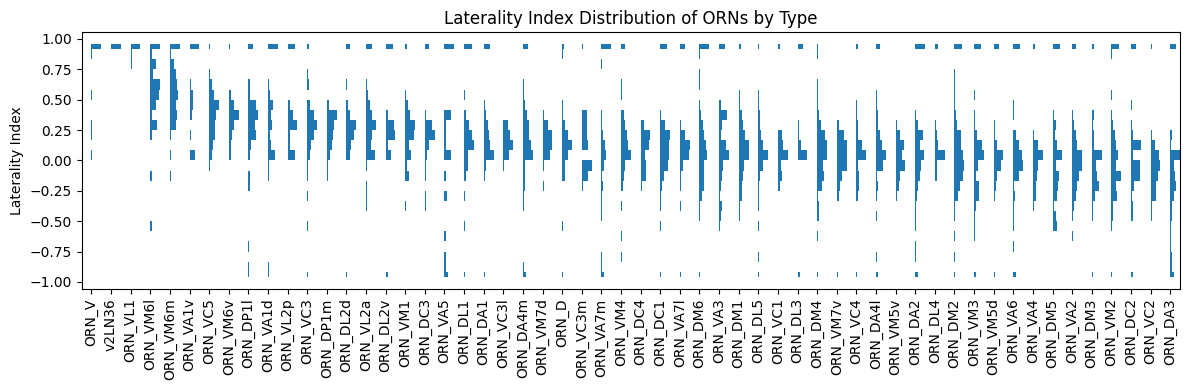

In [54]:
def mirrored_histogram_violin(df, x, y, bins=20, width=0.8, ax=None, order=None, **hist_kwargs):
    """
    Draw a violin-like histogram for each category by mirroring histograms horizontally.
    - x: categorical column name
    - y: numeric column name
    - bins: number of bins (or bin edges) for histogram
    - width: total width allocated per “violin”
    - order: list specifying the order of the categorical values on the x-axis 
    - hist_kwargs: passed to np.histogram (e.g. density=True, etc.)
    """
    if ax is None:
        fig, ax = plt.subplots()

    cats = order if order is not None else df[x].unique()
    n = len(cats)
    spacing = width  # spacing between centers
    half_width = width / 2

    for i, cat in enumerate(cats):
        ys = df.loc[df[x] == cat, y].dropna().values
        if len(ys) == 0:
            continue

        # compute histogram
        counts, bin_edges = np.histogram(ys, bins=bins, **hist_kwargs)

        # bin centers
        centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        # normalize to max width (so the largest histogram reaches half_width)
        max_count = counts.max()
        scale = half_width / max_count if max_count > 0 else 0

        # # left side (mirror)
        # ax.fill_betweenx(
        #     centers,
        #     i * spacing - counts * scale,
        #     i * spacing,
        #     step='mid',
        #     facecolor='C0',
        #     alpha=0.6
        # )
        # right side
        ax.fill_betweenx(
            centers,
            i * spacing,
            i * spacing + counts * scale,
            step='mid',
            facecolor='C0',
            alpha=1
        )

    # set x ticks at the center positions
    ax.set_xticks(np.arange(n) * spacing)
    ax.set_xticklabels(cats)
    ax.set_xlim(-spacing * 0.5, spacing * (n - 0.5))
    return ax

fig, ax = plt.subplots(figsize=(12, 4))
mirrored_histogram_violin(result_df, x='ORN_type', y='LI_synapse', bins=np.linspace(-1, 1, 25), width=0.5, ax=ax, order=order, density=True)
ax.set_ylabel('Laterality Index')
ax.set_title('Laterality Index Distribution of ORNs by Type')
plt.xticks(rotation=90)
plt.tight_layout()